In [2]:
import os
import cv2
import numpy as np
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import ffmpeg
import ipdb
import torch
import tqdm
import matplotlib.pyplot as plt
# import seaborn as sns
import matplotlib.patches as patches
from random import sample 
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
def plot_robot_xyplane_stats(action_points, state_points, save_name):
    points_np = action_points.numpy()[...,:2]
    points_np2 = state_points.numpy()[...,:2]
    # Plot
    plt.figure(figsize=(8, 6))
    # fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    plt.scatter(points_np[:, 0], points_np[:, 1],
                s=2,               # dot size
                c='red',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.scatter(points_np2[:, 0], points_np2[:, 1],
                s=2,               # dot size
                c='blue',          # dot color
                alpha=.1)        # transparency to emphasize density
    # patches.Rectangle((-0.6,))
    plt.axis([-0.6,0.6,-1.295,-0.095])
    plt.title('Robot EEF on XY plane')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    legend = plt.legend(['action','state'])

    for handle in legend.legend_handles:
        handle.set_alpha(1)
    plt.savefig(f'/root/PI_Official/data/visualization/XYPlane/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    

def plot_singledim_stats(action_points, state_points, save_name):
    points_np = action_points.numpy()
    points_np2 = state_points.numpy()
    data = np.concatenate([points_np2[::2], points_np2[1::2]],1)
    # points = np.concatenate([points_np, points_np2], axis = 0)
    # data = points.T
    print(f'data shape {data.shape}')

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, patch_artist=True)
    plt.title("Boxplot of Each EEF Dimension")
    plt.ylabel("EEF Value")
    plt.xticks(range(1, 7), ['L_X','L_Y','L_Z','R_X','R_Y','R_Z'])  # label x-axis from Dim 0 to Dim 13
    plt.grid(True)
    plt.tight_layout()
    os.makedirs('/root/PI_Official/data/visualization/XYZ_BoxPlot', exist_ok = True)
    plt.savefig(f'/root/PI_Official/data/visualization/XYZ_BoxPlot/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

def cal_cmd_vel(state_points, delta = 3):
    state_points = state_points.numpy()
    left_points = state_points[::2]
    right_points = state_points[1::2]
    diff = left_points[delta:] - left_points[:-delta]
    left_mean = np.sqrt(np.sum(diff*diff, axis=1)).mean()
    diff = right_points[delta:] - right_points[:-delta]
    right_mean = np.sqrt(np.sum(diff*diff, axis=1)).mean()
    return (left_mean + right_mean)/2

def cal_cmd_state_diff(action_points, state_points):
    action_points = action_points.numpy()
    state_points = state_points.numpy()
    diff = action_points - state_points
    return np.sqrt(np.sum(diff*diff, axis=1)).mean()

In [3]:
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
repo_id='YC_MultiTask_PutPlateOnRack_0510_11'
sample_num = 20_000

dataset = LeRobotDataset(repo_id, local_files_only=True)
action_points = []
state_points = []
for i in tqdm.tqdm(sample(range(len(dataset)),sample_num)):

    item = dataset[i]
    action_points.append(item['actions'][:3])
    action_points.append(item['actions'][7:10])
    state_points.append(item['observation.state'][:3])
    state_points.append(item['observation.state'][7:10])

action_points = torch.stack(action_points)
state_points = torch.stack(state_points)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MultiTask_PutPlateOnRack_0510_11` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_MultiTask_PutPlateOnRack_0510_11` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/2047 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/279 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [03:52<00:00, 86.11it/s] 


data shape (20000, 6)


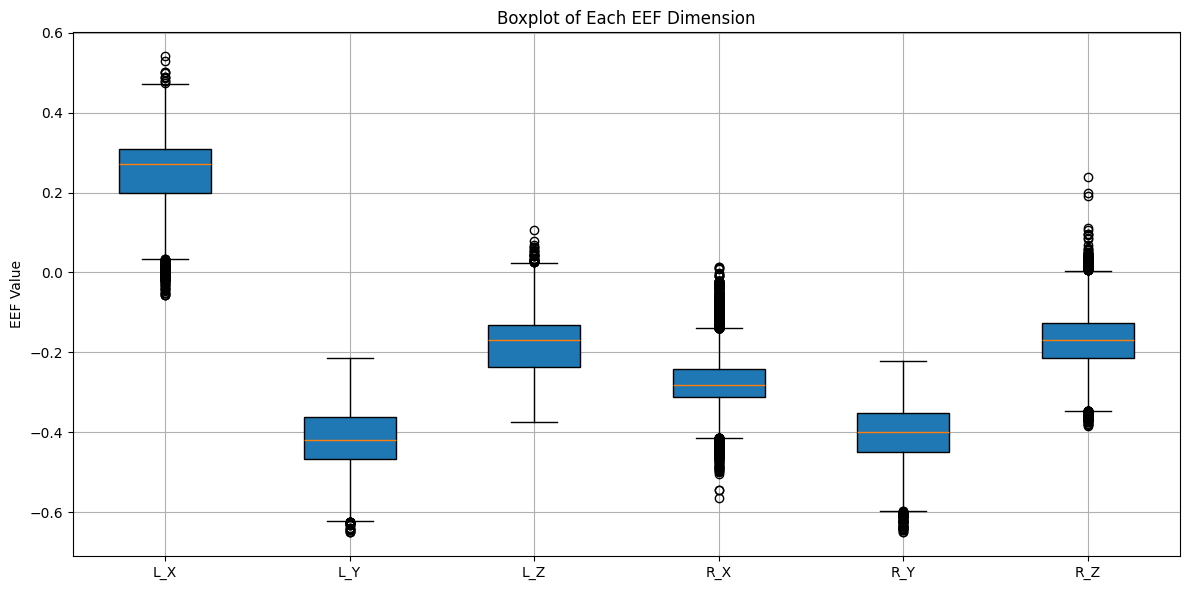

In [4]:
# plot_robot_xyplane_stats(action_points, state_points, repo_id)
plot_singledim_stats(action_points, state_points, repo_id)

In [1]:
cmd_state_diff = cal_cmd_state_diff(action_points, state_points)

# inds = find_outliers(cmd_state_diff)
inds = cmd_state_diff > 0.01
print(f'command state average difference is {cmd_state_diff.mean()}m')
print(f'{inds.sum()*50/sample_num}% points has cmd-state diff larger than 0.01m')
print(f'max cmd-state diff is {cmd_state_diff.max()}m')
# plot_robot_xyplane_stats(action_points[inds], state_points[inds], repo_id + '_outliers')

NameError: name 'cal_cmd_state_diff' is not defined

In [12]:
!export XDG_CACHE_HOME=/pfstem/likaiyu/resources/.cache
repo_id='YC_PutPenInBox_Rjoints_0514_15'
sample_num = 10_000

dataset = LeRobotDataset(repo_id, local_files_only=True)
action_points = []
state_points = []
for i in tqdm.tqdm(sample(range(len(dataset)),sample_num)):

    item = dataset[i]
    action_points.append(item['actions'][2:])
    state_points.append(item['observation.state'][2:])

action_points = torch.stack(action_points)
state_points = torch.stack(state_points)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_PutPenInBox_Rjoints_0514_15` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_PutPenInBox_Rjoints_0514_15` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/633 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/290 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:58<00:00, 170.75it/s]


In [13]:
def plot_angle_limit_violation(state_points, save_name, threshold = 5, sample_num = 10_000):
    left_angle_limit = [
    [-180,60],[-180,3],[-175,175],[-129,90],[-175,175],[-95,95],[-90,90]
    ]
    right_angle_limit = [
        [-60,180],[-180,3],[-175,175],[-90,129],[-175,175],[-95,95],[-90,90]
    ]
    joint_names = [f'LJ{i}' for i in range(1,8)] + [f'RJ{i}' for i in range(1,8)]
    left_angle_limit = np.array(left_angle_limit)
    right_angle_limit = np.array(right_angle_limit)
    angle_limit = np.concatenate([left_angle_limit,right_angle_limit])

    state_points = 180 * state_points/np.pi
    state_points = state_points.numpy()
    up_violation = np.sum(np.int8(state_points >= angle_limit[:,1]-threshold),axis=0)
    down_violation = np.sum(np.int8(state_points <= angle_limit[:,0]+threshold),axis=0)
    plt.figure(figsize=(8, 6))
    plt.bar(joint_names, up_violation*100/sample_num,color='skyblue',alpha=.5)
    plt.bar(joint_names, down_violation*100/sample_num,color='yellow',alpha=.5)
    legend = plt.legend(['up-limit','down-limit'])
    for handle in legend.legend_handles:
        handle.set_alpha(1)
    plt.title('Angle Limit Violation By Joint')
    # plt.xlabel('X')
    plt.ylabel('Probability of Violation')
    plt.savefig(f'/root/PI_Official/data/visualization/Joint_Limit/{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

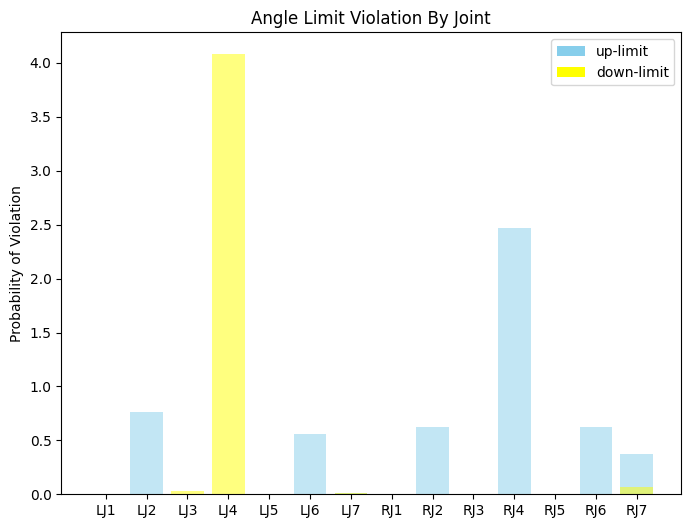

In [14]:
plot_angle_limit_violation(state_points, repo_id)